# Counterfactual Analysis

In [58]:
import warnings
import joblib
import json
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier


from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score

from pathlib import Path
import shutil
import sys 
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig

import dice_ml

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load / Reload Selection Utility Functions

In [2]:
from utils2 import explainability as exp
from utils2 import counterfactuals as cf

----

## Read Config File

In [3]:
config_path = Path(r'experiments')
config_filename =  "bin_cf_final.yml"
config_dict = ymlconfig.load_config(config_path / config_filename)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict


{'experiment': {'summary': 'binary classification - Counterfactual Analysis (Final)',
  'classification_type': 'binary',
  'stage': 'counterfactuals',
  'tag': 'final',
  'verbosity': 1,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'model': {'code': 'catboost', 'name': 'CatBoost'},
 'explainability': {'ksplit_trained_model_results_file': 'binary\\explainability\\catboost\\final\\catboost_ksplit_trained_models.joblib',
  'rundate': '2026-03-18',
  'tag': 'final'},
 'dice': {'method': 'genetic'}}

#### Set output directory

In [4]:
outputdir = config_path /  config.experiment.classification_type /  config.experiment.stage / config.model.code / config.experiment.tag 
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\counterfactuals\catboost\final


#### Copy config file to output directory

In [5]:
source = config_path / config_filename
destination = outputdir / config_filename
shutil.copy(source, destination)

WindowsPath('experiments/binary/counterfactuals/catboost/final/bin_cf_final.yml')

### Load and verify ksplit_trained_model_results_file from Explainability Stage

In [6]:
ksplit_trained_models = joblib.load(config_path / config.explainability.ksplit_trained_model_results_file)
assert ksplit_trained_models['rundate'] == config.explainability.rundate, f"{ksplit_trained_models['rundate']} != {config.explainability.rundate}"
assert ksplit_trained_models['tag'] == config.explainability.tag
print('rundate:', ksplit_trained_models['rundate'])
print('tag:', ksplit_trained_models['tag'])
ksplit_trained_models['summary']

rundate: 2026-03-18
tag: final


,0,1,2,mean,std
youden,0.909,0.727,0.784,0.807,0.076
roc_auc,0.983,0.986,0.944,0.971,0.019


In [7]:
split_results = ksplit_trained_models['results']
split_results[0]

{'model': <catboost.core.CatBoostClassifier at 0x21daeda34d0>,
 'X_train':      SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0      1  64.0     1     7.0      1.0  15.00    0     0         0    0    0   
 1      0  59.0     1     1.0      0.0   5.60    1     0         0    0    0   
 5      0  20.0     1     2.0      1.0   7.80    0     0         0    0    0   
 6      0  69.0     0     0.0      0.0   8.00    1     0         1    0    0   
 7      0  60.0     0     2.0      0.0   5.80    1     0         0    0    0   
 8      1  62.0     0     0.0      1.0  14.36    0     0         0    0    0   
 9      0  44.0     1    17.0      0.0   7.01    0     0         0    0    0   
 10     0  70.0     0    10.0      0.0   6.40    1     0         0    1    0   
 11     1  61.0     1     4.0      0.0   8.30    0     0         1    1    0   
 12     1  57.0     1     7.0      1.0  13.00    0     0         1    0    0   
 14     0  78.0     1     5.0      0.0   5.00 

## Data Loading

In [8]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type)

dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

In [9]:
dfXy = pd.concat([X, y], axis=1)
X.shape, y.shape, dfXy.shape

((190, 40), (190,), (190, 41))

## Prepare Explainer

In [65]:
midx = 0
X_test = split_results[midx]['X_test']
y_test = split_results[midx]['y_test']
threshold = split_results[midx]['threshold']
dfXy_test = pd.concat([X_test, y_test], axis=1)
X_test.shape, y_test.shape, dfXy_test.shape, threshold

((64, 40), (64,), (64, 41), 0.6352084424142594)

In [66]:
allfeature_cols = dfXy_test.columns.drop('Confirmed_Binary_DPN').to_list()
continuous_cols = dfXy_test.columns.difference(D.categorical_cols+['Confirmed_Binary_DPN']).to_list()
print('all feature columns:\n', len(allfeature_cols), allfeature_cols)
print('categorical columns:\n', len(D.categorical_cols), D.categorical_cols)
print('continuous_columns:\n', len(continuous_cols), continuous_cols)

all feature columns:
 40 ['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C', 'HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI', 'SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R', 'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM', 'NS', 'CAS']
categorical columns:
 12 ['SEX', 'SUBJ', 'INSULIN', 'HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR']
continuous_columns:
 28 ['AGE', 'CAS', 'CMAPANK_L', 'CMAPANK_R', 'CMAPKNE_L', 'CMAPKNE_R', 'DL_L', 'DL_R', 'DM_DUR', 'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'FWAVE_L', 'FWAVE_R', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM', 'HBA1C', 'MCV_L', 'MCV_R', 'MNSI', 'NS', 'SPSA_L', 'SPSA_R', 'SPSC_L', 'SPSC_R', 'SSA_L', 'SSA_R', 'SSC_L', 'SSC_R']


In [67]:
X_train = split_results[midx]['X_train']
X_test = split_results[midx]['X_test']

# convert categorical columns in X_train - needed in CatBoost for use in DiCE
X_train[D.categorical_cols] = X_train[D.categorical_cols].astype(str)
X_test[D.categorical_cols] = X_test[D.categorical_cols].astype(str)

best_params = split_results[midx]['best_params']
y_train = split_results[midx]['y_train']
y_test = split_results[midx]['y_test']

# refit model so we can set cat_features (needed in DiCE)
model=  CatBoostClassifier(**best_params, 
                           cat_features=D.categorical_cols, 
                           verbose=0
                           ).fit(X_train, y_train)

## Global Counterfactual Analysis

###  Define Global Permitted Range

In [68]:
global_permitted_range = cf.get_global_permitted_range(dfXy, continuous_cols, verbosity=1)

,min,max
AGE,8.111,100.889
CAS,0.000,58.027
CMAPANK_L,0.000,29.589
CMAPANK_R,0.000,31.434
CMAPKNE_L,0.000,22.551
CMAPKNE_R,0.000,23.008
DL_L,0.000,48.650
DL_R,0.000,16.399
DM_DUR,0.000,37.797
FEET_MEAN_ESC,0.000,106.560


### Setup Explainer Object

In [70]:

wrapped_model = cf.CatBoostWrapper(model, threshold)
cf.test_wrapped_model(model, wrapped_model, X_test, y_test, threshold)


Confusion Matrix at default threshold (0.5):
[[20  0]
 [ 3 41]]
Confusion Matrix at custom threshold (0.6352084424142594):
[[20  0]
 [ 4 40]]
Rows with different predictions at thresholds: 


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,pred_0.50,pred_0.64,pred_proba
106,1,33.0,1,3.0,1.0,9.0,0,0,0,0,0,0,1,0,1,3.0,4.88,49.2,0.0,0.0,43.2,3.5,13.14,10.75,43.3,2.68,45.3,0.0,0.0,44.0,3.45,9.98,7.18,42.4,76.0,0.0,76.0,12.0,90.0,4.0,1,0,0.524


### Plot Global Importances

100%|██████████| 64/64 [04:37<00:00,  4.33s/it]


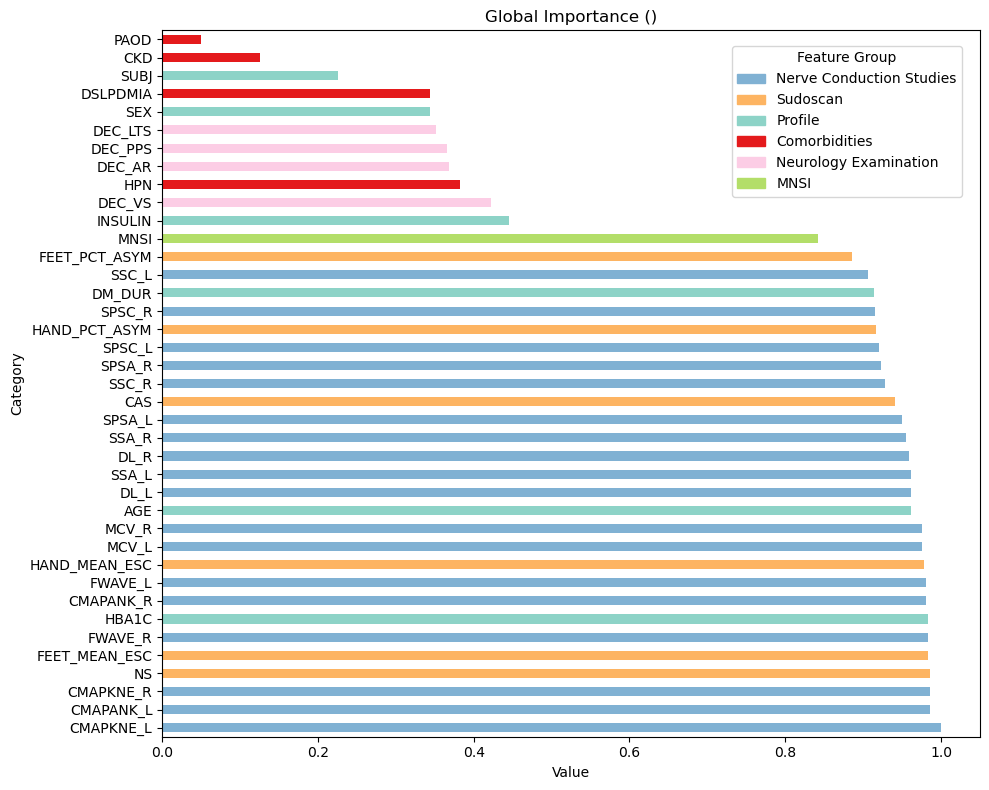

In [71]:
d = dice_ml.Data(dataframe=dfXy_test, # use only the test set
                 continuous_features=continuous_cols,                  
                 categorical_features=D.categorical_cols,
                 permitted_range = global_permitted_range, 
                 outcome_name='Confirmed_Binary_DPN')

m = dice_ml.Model(model=wrapped_model, backend="sklearn", model_type="classifier")
dexp = dice_ml.Dice(d, m, method=config.dice.method)

cf.plot_global_importance(dexp, D, X_test, midx, config, 
                        highlight_features=[], total_CFs=10, 
                        title_suffix="", filename_suffix="", savedir=None)

## Local Counterfactual Analysis

##### Local Permitted Range for Patient Index 40

In [95]:
from utils2 import explainability as exp
from utils2 import counterfactuals as cf

In [96]:
pidx = 40
query_instance = X[pidx:pidx+1]
instance_permitted_range = cf.get_local_permitted_range(
    dfXy, query_instance, allfeature_cols, D.categorical_cols, continuous_cols, cf.progressive_cols)

,40,min,max
SEX,0.00,NaN,NaN
AGE,47.00,47.000,58.889
SUBJ,1.00,NaN,NaN
DM_DUR,14.00,14.000,21.797
INSULIN,1.00,NaN,NaN
HBA1C,10.33,7.615,13.045
HPN,0.00,NaN,NaN
PAOD,0.00,NaN,NaN
DSLPDMIA,1.00,NaN,NaN
CKD,0.00,NaN,NaN


##### Generate 5 Sample Local Counterfactuals for Patient 40

In [ ]:
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=5, 
    desired_class="opposite", 
    permitted_range=instance_permitted_range,
    features_to_vary=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list()
    )    
e1.visualize_as_dataframe(show_only_changes=True) 

#### Inspect logits

In [ ]:
# optimized_model.fit(X_train, y_train) # no longer needed
y_pred = optimized_model.predict(X_val)
y_proba = optimized_model.predict_proba(X_val)[:, 1]

In [ ]:
y_pred

In [ ]:
y_proba

In [ ]:
y_val

### Borderline Local Counterfactuals

#### Generate Borderline Cases

In [ ]:
def get_borderline_cases(model, X, y, threshold=0.5, delta=0.1):
    """Return borderline cases around the decision threshold."""
    y_prob = model.predict_proba(X)[:, 1]
    margin = np.abs(y_prob - threshold)
    
    borderline_idx = np.where(margin <= delta)[0]
    borderline_df = X.iloc[borderline_idx].copy()
    borderline_df["pred_prob"] = y_prob[borderline_idx]
    borderline_df["margin"] = margin[borderline_idx]
    borderline_df["pred_label"] = (y_prob[borderline_idx] >= threshold).astype(int)
    borderline_df["true_label"] = y.iloc[borderline_idx].values
    borderline_df["misclassified"] = borderline_df["pred_label"] != borderline_df["true_label"]
    
    print(f"Found {len(borderline_df)} borderline cases (|p - {threshold}| ≤ {delta})")
    return borderline_df


In [ ]:
borderline_df = get_borderline_cases(optimized_model, X, y, delta=0.2)
borderline_df = borderline_df[D.profile_cols+['pred_prob','margin','pred_label','true_label','misclassified']].sort_values(by='margin')
borderline_df

In [ ]:
borderline_df.to_csv(r'outputs\counterfactuals\local\binary\borderline_df_delta0.2.csv')

In [ ]:
# inspect Patient 40
pidx = 40
dfXy.iloc[pidx:pidx+1]

In [ ]:
pidx = 40
query_instance = X[pidx:pidx+1]
instance_permitted_range = get_local_permitted_range(query_instance, allfeature_cols, continuous_cols, progressive_cols)

In [ ]:
print(f"generating counterfactuals for the {model_name} model")    
e1 = exp.generate_counterfactuals(
    query_instance, total_CFs=5, 
    desired_class="opposite", 
    permitted_range=instance_permitted_range,
    features_to_vary=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list()
    )    
e1.visualize_as_dataframe(show_only_changes=True) 

In [ ]:
e1_cfdf = e1.cf_examples_list[0].final_cfs_df
e1_cfdf

### Prototypical and Atypical

##### Prototypical (most representative)

##### Atypical (deviating from standard/common)

### Generate Local Counterfactuals

#### generate_diverse_cfs Function

In [ ]:
def generate_diverse_cfs(dice_exp, instance, total_CFs=30, features_to_vary='all', permitted_range={}, seeds=[0,1,2,3,4], diversity_weight=1.5):
    """Generate diverse counterfactuals across multiple seeds."""
    all_cfs = []
    for s in seeds:
        # manually set random seed
        np.random.seed(s)
        random.seed(s) 

        cf = dice_exp.generate_counterfactuals(
            instance,
            total_CFs=total_CFs,
            desired_class="opposite",
            features_to_vary=features_to_vary,
            permitted_range=permitted_range,
            #random_seed=s,
            diversity_weight=diversity_weight
        )        
        df_cf = cf.cf_examples_list[0].final_cfs_df
        if not df_cf.empty:
            all_cfs.append(df_cf)
    if all_cfs:
        combined = pd.concat(all_cfs).drop_duplicates().reset_index(drop=True)
        return combined
    else:
        return pd.DataFrame()

#### Patient Index 40 (Patient 41 in Spreadsheet)

##### Generate Counterfactuals

In [ ]:
pidx = 40 # dataframe is zero-indexed
query_instance = X[pidx:pidx+1]
df_dcf = generate_diverse_cfs(
    exp,
    query_instance, total_CFs=30,
    permitted_range=instance_permitted_range,
    features_to_vary=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list()
    )

In [ ]:
df_dcf.tail(5)

In [ ]:
dfXy.columns.__len__()

In [ ]:
df_dcf.columns.__len__()

In [ ]:
n = 55
save_every = 15
[(b, b*15 + save_every) for b in range(int(np.ceil(n/save_every))) ]

In [ ]:
np.ceil(3.4).to

In [ ]:
np.ceil?

In [ ]:
def plot_local_cf_heatmap(df_dcf, query_instance, 
                          pstr, pred, actual, 
                          savedir,
                          save_every=15,  
                          figsize=(15, 6.5)
                          ):   
    # Compute differences (each row in df_large vs. the single row)
    diffs = df_dcf - query_instance.iloc[0]
    print("diffs.shape: ", diffs.shape)
    batch_ranges = [(b*save_every, b*save_every+save_every) for b in range(int(np.ceil(df_dcf.shape[0]/save_every))) ]
    print("batch_ranges: ",  batch_ranges)
    for idx_start, idx_end in batch_ranges:
        print("idx_start, idx_end: ", idx_start, idx_end)
        diff = diffs.iloc[idx_start: idx_end]
        print("diff.shape: ",  diff.shape)
        diff = diff[dfXy.drop('Confirmed_Binary_DPN', axis=1).columns]
        print("diff.shape: ",  diff.shape)

        # Create mask where values == 0
        mask = diff == 0

        # Plot heatmap
        plt.figure(figsize=figsize)
        ax = sns.heatmap(
            diff,
            mask=mask,            # hide zero differences
            cmap="RdBu",        # diverging color map centered at 0
            center=0,
            annot=True,           # show annotations
            fmt=".2f",            # format annotations to 2 decimal places
            annot_kws={"size": 6},# smaller font
            cbar_kws={'label': 'Difference'}
        )

        ax.set_yticks(np.arange(len(diff)) + 0.5)
        ax.set_yticklabels(diff.index, rotation=0, fontsize=8)

        # ✅ Make x-tick labels smaller too
        ax.set_xticklabels(diff.columns, rotation=45, ha='right', fontsize=8)

        # plt.title("Differences from Instance", fontsize=12)
        plt.title(f"Counterfactuals for Patient {pstr}: predicted {pred}, actual {actual}", fontsize=12, pad=20)
        plt.xlabel("Features")
        plt.ylabel("Counterfactuals")

        # 1. Get the feature values from the query instance
        desired_order = diff.columns.tolist() 
        query_instance_reordered = query_instance[desired_order]

        query_values = query_instance_reordered.iloc[0].values
        NEW_Y_POSITION = -0.05 

        # 2. Loop through each feature to place the value text
        for i, value in enumerate(query_values):
            # i + 0.5 centers the text in the column cell.
            # y = -0.3: Increased separation from the heatmap for visual clarity/alignment.
            ax.text(
                x=i + 0.5,
                y=NEW_Y_POSITION, #-0.3, # Adjusted from -0.2 to -0.3
                s="0" if value==0 else "1" if value==1 else f"{value:.2f}",  # Display the value, formatted
                ha='center',
                va='bottom',
                fontsize=6,
                # fontweight='bold',
                color='#1a1a1a' # Slightly darker color for visibility
            )

        # 3. Add a row header label for the new values
        ax.text(
            x=-0.5, # Position to the left of the Y-axis labels
            y=NEW_Y_POSITION, #-0.3, # Adjusted from -0.2 to -0.3
            s="Instance Values:",
            ha='right',
            va='bottom',
            fontsize=6,
            # fontweight='bold',
            color='#1a1a1a' # Slightly darker color for visibility
        )

        plt.tight_layout()
        os.makedirs(os.path.join(savedir, pstr), exist_ok=True)
        idx_end = min(idx_end, idx_start+diff.shape[0])
        fullfilepath = os.path.join(savedir, pstr, f"local_counterfactual_{pstr}_idx{idx_start}-idx{idx_end-1}.png")
        plt.savefig(fullfilepath)


In [ ]:
plot_local_cf_heatmap(df_dcf, query_instance, 
                      pstr="040", pred=0, actual=1, 
                      savedir=r"outputs\counterfactuals\local\binary" , save_every=15, figsize=(15, 6.5))

##### Get Most Changed Features

In [ ]:
def get_most_changed_feature(df_cf, instance):
    # Boolean mask: True if feature changed compared to the original instance
    changed_mask = df_cf.ne(instance.iloc[0])

    # Count how many counterfactuals changed each feature
    change_counts = changed_mask.sum()
    change_counts = change_counts.sort_values(ascending=False)
    return change_counts

most_changed_features = get_most_changed_feature(df_dcf, query_instance)
most_changed_features

In [ ]:
most_changed_features = most_changed_features.drop('Confirmed_Binary_DPN')
most_changed_features

##### Analyze Sparsity and L1, L2 Distances

In [ ]:
def analyze_local_cf(instance_df, cf_df, feature_costs=None):
    """
    Compute distances, sparsity, and feasibility per counterfactual.
    feature_costs: optional dict of feature->cost weights
    """
    if cf_df.empty:
        return pd.DataFrame()

    x0 = instance_df.iloc[0]
    diffs = cf_df.sub(x0)
    sparsity = (diffs != 0).sum(axis=1)   # number of columns altered
    l1 = np.abs(diffs).sum(axis=1)        
    l2 = np.sqrt((diffs**2).sum(axis=1))

    cf_df["sparsity"] = sparsity
    cf_df["L1_dist"] = l1
    cf_df["L2_dist"] = l2

    if feature_costs:
        cf_df["cost"] = sum(np.abs(diffs[f]) * feature_costs.get(f, 1) for f in diffs.columns)

    cf_df.sort_values("L1_dist").reset_index(drop=True)
    
    # generate a dataframe with the diffs and the analysis
    diffs = cf_df.drop(columns=['sparsity', 'L1_dist', 'L2_dist']).sub(x0)     
    diffs = pd.concat([diffs, cf_df[['sparsity', 'L1_dist', 'L2_dist']]], axis=1)
    return diffs,  cf_df

In [ ]:
diffs, cf_ana = analyze_local_cf(query_instance, df_dcf)

In [ ]:
diffs.head()

##### Visualize top 5 counterfactuals closest to instance

In [ ]:
# check top 5 counterfactuals closest to instance
cf_ana[D.profile_cols+['sparsity','L1_dist','L2_dist']].head(5)

#### Filter Valid Counterfactuals

In [ ]:
query_instance

In [ ]:
progressive_categorical_cols = list(set(progressive_cols) & set(D.categorical_cols))
progressive_categorical_cols

In [ ]:
# check progressive categorical values of instance; filter out invalid CF: those that go from 1 to 0
query_instance[progressive_categorical_cols]
# all are 0, so all are valid counterfactuals; nothing to filter 


In [ ]:
cf_ana

#### Sufficiency

A sufficient feature  change is one that can cause the outcome change by itself.


In [ ]:
def check_sufficiency(dice_exp, instance, all_features, permitted_range, desired_class="opposite", 
                      maxiterations=500):
    """Determine necessity and sufficiency of each feature for one instance."""
    results = {}
    for f in all_features:
        results[f] = {"sufficient": "False"}
        print(f)

        # --- Sufficiency: vary only this feature  ---
        try:
            cf_suf = dice_exp.generate_counterfactuals(
                instance, total_CFs=1, desired_class=desired_class, features_to_vary=[f], 
                permitted_range=permitted_range, maxiterations=maxiterations,
            )
            if len(cf_suf.cf_examples_list[0].final_cfs_df) > 0:
                results[f]["sufficient"] = "True"
            print(f'Successfully calculated sufficiency for {f}')
        except Exception as e:
            print(f'Error calculating sufficiency for {f}')
            print(f'{e}')
            pass
        print('sufficienct: ', results[f]["sufficient"])

    return pd.DataFrame(results).T.reset_index(names="feature")

In [ ]:
most_changed_features = most_changed_features.index.to_list()
sufficient_features = ['SSA_R', 'SSA_L', 'DL_L']
forced_timeout_features = ['HBA1C',  'DEC_AR', 'DEC_VS', 'DEC_LTS', 'DEC_PPS', 'CMAPKNE_L', 'FEET_PCT_ASYM', 'INSULIN', 'HPN', 'HAND_PCT_ASYM',  'DSLPDMIA', 'DL_R']
# Other exception: 'SPSA_R'
# No CF exception: 'SPSA_L', 'CMAPANK_L', 'MCV_L', 

#check_features = forced_timeout_features
check_features = sufficient_features
print(check_features)


In [ ]:
df_s = check_sufficiency(
    exp,
    query_instance,
    #all_features=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list()[:3],
    all_features=check_features,
    maxiterations=2000,
    permitted_range=instance_permitted_range,
    )
df_s

In [ ]:
import time
import numpy as np
import random
import pandas as pd
from tqdm import tqdm
from multiprocessing import Process, Queue

def run_dice_in_process(queue, dice_exp, instance, total_CFs, desired_class,
                        features_to_vary, permitted_range, maxiterations):
    """Run DiCE in a separate process so it can be timed out."""
    try:
        cf_suf = dice_exp.generate_counterfactuals(
                        instance, total_CFs=total_CFs, desired_class=desired_class, features_to_vary=features_to_vary, 
                        permitted_range=permitted_range, maxiterations=maxiterations,
                    )
        queue.put(cf_suf)
    except Exception as e:
        queue.put(e)

def generate_cfs_with_timeout(timeout_sec, dice_exp, instance, total_CFs, desired_class,
                          features_to_vary, permitted_range, maxiterations):
    """Run generate_counterfactuals() with timeout control."""
    q = Queue()
    p = Process(
        target=run_dice_in_process,
        args=(q, dice_exp, instance, total_CFs, desired_class,
              features_to_vary, permitted_range, maxiterations)
    )
    p.start()
    p.join(timeout=timeout_sec)

    if p.is_alive():
        p.terminate()
        p.join()
        return None  # Timeout occurred

    result = q.get() if not q.empty() else None
    if isinstance(result, Exception):
        raise result
    return result

def check_sufficiency_with_timeout(dice_exp, instance, all_features, permitted_range, 
                      desired_class="opposite", 
                      maxiterations=500, timeout_sec=30*60):
    """Determine sufficiency of each feature for one instance."""

    results = {}
    for f in tqdm(all_features):
        results[f] = {"sufficient": "False"}
        print(f)

        try:
            cf_suf = generate_cfs_with_timeout(
                timeout_sec, dice_exp, instance, total_CFs=1, desired_class=desired_class, features_to_vary=[f], 
                permitted_range=permitted_range, maxiterations=maxiterations,
            )

            # timeout
            if cf_suf is None:
                print(f"⏰ Timeout (>{timeout_sec//60} min) for feature '{f}' — skipping to next.")
                results[f]["sufficient"] = "Timeout"
                continue

            if len(cf_suf.cf_examples_list[0].final_cfs_df) > 0:
                results[f]["sufficient"] = "True"

        except Exception as e:
            print(f'Error calculating sufficiency for {f}')
            print(f'{e}')
            results[f]["sufficient"] = "Error"
            
        print('sufficient: ', results[f]["sufficient"])

    return pd.DataFrame(results).T.reset_index(names="feature")



In [ ]:
df_s = check_sufficiency_with_timeout(
    exp,
    query_instance,
    #all_features=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list()[:3],
    all_features=check_features,
    maxiterations=500,
    permitted_range=instance_permitted_range,
    timeout_sec=5
    )
df_s

#### Necessity

A necessary feature change is one that must be altered; without it, no counterfactual achieves the desired outcome.

In [ ]:
def check_necessity(dice_exp, instance, all_features, permitted_range, desired_class="opposite", 
                    maxiterations=500, total_CFs=3, seeds=[0,1,2,3,4]):
    """Determine necessity (vary all except this one across multiple seeds) of each feature for one instance."""
    results = {}
    for f in tqdm(all_features):
        results[f] = {"necessary": False}       
        # --- Necessity: vary all except this one across multiple seeds ---
        features_wo_f = [feat for feat in all_features if feat != f]
        found_cf = False
        for seed in seeds:
        
            # manually set random seed
            np.random.seed(seed)
            random.seed(seed) 

            cf_nec = dice_exp.generate_counterfactuals(
                instance, total_CFs=3, desired_class=desired_class,
                features_to_vary=features_wo_f, permitted_range=permitted_range, 
                maxiterations=maxiterations,
                #random_seed=seed
            )
            if len(cf_nec.cf_examples_list[0].final_cfs_df) > 0:
                found_cf = True
                break

        if not found_cf:
            results[f]["necessary"] = True
    return pd.DataFrame(results).T.reset_index(names="feature")

In [ ]:
df_ns = check_necessity(
    exp,
    query_instance,
    all_features=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list(),
    maxiterations=500,
    total_CFs=2,
    permitted_range=instance_permitted_range,
    seeds=[0,1,2,3,4], 
    )
df_ns

### Generate Files for Counterfactuals by batch

#### Setup

In [ ]:
D = DPN_data("../dataset/Sudoscan Working File with Stats.xlsx")
D.load(classification="binary")
df = D.df
data_cols = df.drop(D.non_data_cols, axis=1, errors="ignore").columns

X = df[data_cols]
y = df['Confirmed_Binary_DPN']
dfXy = pd.concat([X, y], axis=1)

allfeature_cols = dfXy.columns.drop('Confirmed_Binary_DPN').to_list()
continuous_cols = dfXy.columns.difference(D.categorical_cols+['Confirmed_Binary_DPN']).to_list()

actionable_cols = ['HBA1C', 'DSLPDMIA', 'INSULIN']
progressive_cols = ['AGE', 'DM_DUR', 'HPN', 'PAOD', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR', 'MNSI']
immutable_cols = ["SEX"]


global_permitted_range = get_global_permitted_range(continuous_cols)

d = dice_ml.Data(dataframe=dfXy, 
                 categorical_features = D.categorical_cols,
                 continuous_features=continuous_cols,                  
                 permitted_range = global_permitted_range,                 
                 outcome_name='Confirmed_Binary_DPN')
m = dice_ml.Model(model=optimized_model, backend="sklearn", model_type="classifier")
exp = dice_ml.Dice(d, m, method="genetic")

In [ ]:
dfb = pd.read_csv(r'outputs\counterfactuals\local\binary\borderline_df_delta0.2.csv', index_col=0)
pindices = dfb.index.to_list()
dfb

In [ ]:
def plot_local_cf_heatmap(df_dcf, query_instance, 
                          pstr, pred, actual, 
                          savedir,
                          save_every=15,  
                          figsize=(15, 6.5)
                          ):   
    # Compute differences (each row in df_large vs. the single row)
    
    diffs = df_dcf - query_instance.iloc[0]
    batch_ranges = [(b*save_every, b*save_every+save_every) for b in range(int(np.ceil(df_dcf.shape[0]/save_every))) ]
    for idx_start, idx_end in batch_ranges:
        print("idx_start, idx_end: ", idx_start, idx_end)
        diff = diffs.iloc[idx_start: idx_end]
        diff = diff[dfXy.drop('Confirmed_Binary_DPN', axis=1).columns]

        # Create mask where values == 0
        mask = diff == 0

        # Plot heatmap
        plt.figure(figsize=figsize)
        ax = sns.heatmap(
            diff,
            mask=mask,            # hide zero differences
            cmap="RdBu",        # diverging color map centered at 0
            center=0,
            annot=True,           # show annotations
            fmt=".2f",            # format annotations to 2 decimal places
            annot_kws={"size": 6},# smaller font
            cbar_kws={'label': 'Difference'}
        )

        ax.set_yticks(np.arange(len(diff)) + 0.5)
        ax.set_yticklabels(diff.index, rotation=0, fontsize=8)

        # ✅ Make x-tick labels smaller too
        ax.set_xticklabels(diff.columns, rotation=45, ha='right', fontsize=8)

        # plt.title("Differences from Instance", fontsize=12)
        plt.title(f"Counterfactuals for Patient {pstr}: predicted {pred}, actual {actual}", fontsize=12, pad=20)
        plt.xlabel("Features")
        plt.ylabel("Counterfactuals")

        # 1. Get the feature values from the query instance
        desired_order = diff.columns.tolist() 
        query_instance_reordered = query_instance[desired_order]

        query_values = query_instance_reordered.iloc[0].values
        NEW_Y_POSITION = -0.05 

        # 2. Loop through each feature to place the value text
        for i, value in enumerate(query_values):
            # i + 0.5 centers the text in the column cell.
            # y = -0.3: Increased separation from the heatmap for visual clarity/alignment.
            ax.text(
                x=i + 0.5,
                y=NEW_Y_POSITION, #-0.3, # Adjusted from -0.2 to -0.3
                s="0" if value==0 else "1" if value==1 else f"{value:.2f}",  # Display the value, formatted
                ha='center',
                va='bottom',
                fontsize=6,
                # fontweight='bold',
                color='#1a1a1a' # Slightly darker color for visibility
            )

        # 3. Add a row header label for the new values
        ax.text(
            x=-0.5, # Position to the left of the Y-axis labels
            y=NEW_Y_POSITION, #-0.3, # Adjusted from -0.2 to -0.3
            s="Instance Values:",
            ha='right',
            va='bottom',
            fontsize=6,
            # fontweight='bold',
            color='#1a1a1a' # Slightly darker color for visibility
        )

        plt.tight_layout()
        os.makedirs(os.path.join(savedir, pstr), exist_ok=True)
        idx_end = min(idx_end, idx_start+diff.shape[0])
        fullfilepath = os.path.join(savedir, pstr, f"local_counterfactual_{pstr}_idx{idx_start}-idx{idx_end-1}.png")
        plt.savefig(fullfilepath)

In [ ]:
import os
def generate_local_cf_reports(X, exp, dfb, pidx, 
                              savedir, 
                              features_to_vary,
                              total_CFs=30,
                              seeds=[0,1,2,3,4]):
    query_instance = X[pidx:pidx+1]
    instance_permitted_range = get_local_permitted_range(query_instance, allfeature_cols, continuous_cols, progressive_cols)

    print('Generating Counterfactuals...')
    df_dcf = generate_diverse_cfs(
        exp,
        query_instance, total_CFs=total_CFs,
        permitted_range=instance_permitted_range,
        features_to_vary=features_to_vary,
        seeds=seeds,
        )
    pstr =str(pidx).zfill(3)
    os.makedirs(os.path.join(savedir, pstr), exist_ok=True)
    df_dcf.to_csv(os.path.join(savedir, pstr, f"local_cf_patient_{pstr}.csv"))

    plot_local_cf_heatmap(df_dcf, query_instance, 
                        pstr=pstr, 
                        pred=dfb.loc[pidx].pred_label, 
                        actual=dfb.loc[pidx].true_label, 
                        savedir=savedir, save_every=15, figsize=(15, 6.5))    
    
    most_changed_features = get_most_changed_feature(df_dcf, query_instance).reset_index()
    most_changed_features.columns = ['feature', 'change count']
    most_changed_features.to_csv(os.path.join(savedir, pstr, f"local_cf_most_changed_patient_{pstr}.csv"))


#### Batch process

In [ ]:
for pidx in pindices: 
    print(f"Generating counterfactual analysis for patient {pidx}")
    generate_local_cf_reports(X, exp, dfb, pidx, 
                              savedir=r"outputs\counterfactuals\local\binary",
                              features_to_vary=dfXy.columns.drop(['SEX', 'Confirmed_Binary_DPN']).to_list(), 
                              total_CFs=30,
                              seeds=[0,1,2,3,4],
                              )
    